#### Name: Tim Book

# PHYS 230 Lab Assignment 16

### Monday, April 6, 2026: Chapter 8.6
- Boundary Value Problems

*Don't forget to put a markdown cell at the end of each problem explaining your process and results AND comments in all cells*

In [16]:
# import statements here

import numpy as np
import matplotlib.pyplot as plt

### The Shooting Method

Find a solution to the boundary value problem: 
$$\frac{d^2y}{dt^2} = -y$$
where $y$ is the position of an object, and $y(t=0) = 1$ and $y(t=1) = 2$. To do this, complete the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. (Convert the cell below to markdown first)

$$\frac{dv}{dt} = -y$$
$$\frac{dy}{dt} = v$$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1 using a vector `r` that containts two elements. 

In [2]:
def f(r,t):
    y=r[0]
    v=r[1]
    fy = v
    fv = -y
    return np.array([fy,fv],float)

#### Step 3: Define any constants, boundary conditions, and arrays necessary for the problem and solve for the initial velocity $\left(\frac{dy}{dt}\right)$. 

In [28]:
y0 = 1
y1 = 2

t1 = 0.0
t2 = 1.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2,h)

#### Step 4: Use fourth-order Runge-Kutta combined with the binary search method to find the initial velocity ($\frac{dy}{dt}$) that solves the boundary value problem. Note: in this case the final point is not 0. In order to use binary search, you will need to subtract the final height from the runge-kutta found height using your initial guess to see if it is zero or not. 

In [29]:
def RK4(v, tpts, h):
    #tpts = array of time values spaced by h
    #v = initial velocity guess 
    r = np.array([y0,v],float) 
    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1, t+0.5*h)
        k3 = h*f(r+0.5*k2, t+0.5*h)
        k4 = h*f(r+k3, t+h)
        r += (k1+2*k2+2*k3+k4)/6 
    return r[0] - y1

#print(RK4(1.5,tpts,h))

targetacc = 1e-8
v1 = 0.01
v2 = 10.0
h1 = RK4(v1,tpts,h)
h2 =RK4(v2,tpts,h)

while abs(h2 - h1) > targetacc:
    vp = (v1+v2)/2
    hp = RK4(vp,tpts,h)
    if h1*hp >0:
        v1 = vp
        h1 =hp
    else:
        v2 = vp
        h2 =hp
v = (v1 + v2)/2
print(v)

1.7346975948335603


#### Step 5: Analyze the accuracy of your result. One way you could do this is to plug your two now initial conditions back into fourth-order runge-kutta to solve for all $y$ values and make a plot of $y$ vs. $t$. In a markdown cell, briefly comment on the results. 

1.999999999336627


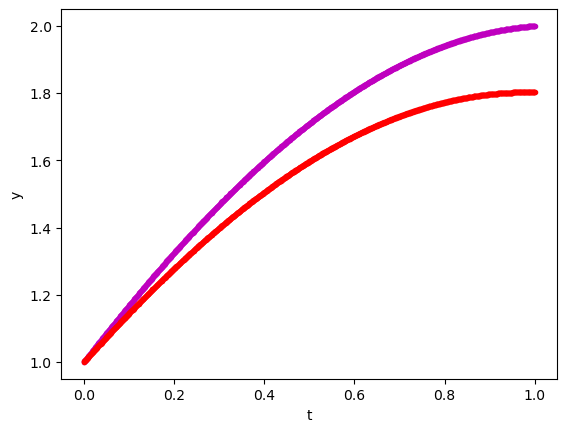

1.8025087830799857


In [31]:
tpts = np.arange(t1,t2+h,h)
ypts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

r = np.array([y0,v],float)
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i])
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h*f(r+k3, tpts[i]+h)
    r += (k1+2*k2+2*k3+k4)/6

plt.plot(tpts,ypts,".m")
plt.xlabel("t")
plt.ylabel("y")


print(ypts[-1])

r = np.array([y0,1.5],float)
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i])
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h*f(r+k3, tpts[i]+h)
    r += (k1+2*k2+2*k3+k4)/6

plt.plot(tpts,ypts,".r")
plt.show()

print(ypts[-1])

### Eigenvalue Problems 

Find the smallest positive eigenvalue $z$ for the equation:
	    $$\frac{d^2y}{dt^2} = -z y$$
	    where $y(t =-1) = 0$ and $y(t = 1) = 0$. Try searching in the range $0.0 \leq z \leq 10.0$. To do this, complete the following steps:

#### Step 1: define the function `f(r,t,z)` that applies values (including your initial guess of $z$ and a vector `r` that containts two elements) to the two first-order differential equations needed for this problem. You may find it beneficial to write our your two first-order differential equations first. 

In [48]:
#dv/dt = -zy
#dy/dt = v

def f(r,t,z):
    y=r[0]
    v=r[1]
    fy = v
    fv = -z*y
    return np.array([fy,fv],float)

#### Step 2: Define any constants, time constraints, and initial/boundary values necessay to apply fourth-order runge-kutta and either the binary search or secant method to solve this problem

In [52]:
y1 = 0
y2 = 0

t1 = -1.0
t2 = 1.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2,h)

z1 = 0.0
z2 = 10.0

#### Step 3: Solve for $z$ using fourth-order runge-kutta and the root method of your choice (binary, secant)

In [57]:
def newRK4(z): 
    r = np.array([0.0,1.0],float)

    for t in tpts:
        k1 = h*f(r,t,z)
        k2 = h*f(r+0.5*k1, t+0.5*h, z)
        k3 = h*f(r+0.5*k2, t+0.5*h, z)
        k4 = h*f(r+k3, t+h, z)
        r += (k1+2*k2+2*k3+k4)/6
    return r[0]

y2 = newRK4(z1)

targetacc = 1e-10
while abs(z1-z2) > targetacc:
    y1,y2 = y2,newRK4(z2)
    z1,z2 = z2,z2-y2*(z1-z2)/(y1-y2)
print(z2)

print(z2/4)

9.869604401345722
2.4674011003364305


#### Step 4: Does your value of $z$ make sense? Show below by plugging initial conditions back into fourth-order Runge-Kutta and plotting $y$ vs. $t$. What happens if you change the initial guess of $v = \frac{dy}{dt}$? 

-7.463647755390213e-16


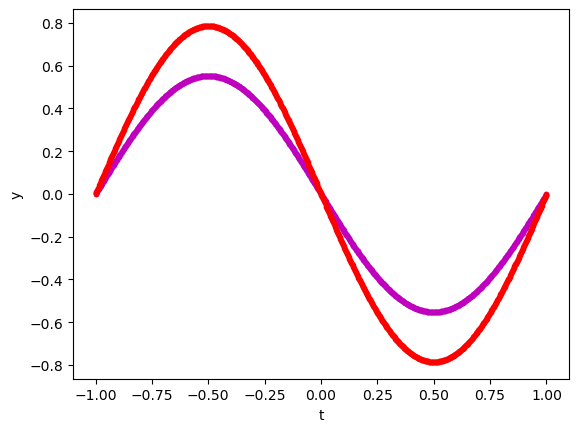

-4.111294638065033e-16


In [62]:
tpts = np.arange(t1,t2+h,h)
ypts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

r = np.array([0,v],float)
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i],z2)
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h,z2)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h,z2)
    k4 = h*f(r+k3, tpts[i]+h,z2)
    r += (k1+2*k2+2*k3+k4)/6

plt.plot(tpts,ypts,".m")
plt.xlabel("t")
plt.ylabel("y")


print(ypts[-1])

r = np.array([0,z2/4],float)
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i],z2)
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h,z2)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h,z2)
    k4 = h*f(r+k3, tpts[i]+h,z2)
    r += (k1+2*k2+2*k3+k4)/6

plt.plot(tpts,ypts,".r")
plt.show()

print(ypts[-1])